# Notebook 01 — Exploración y preparación de datos

Queremos predecir el abandono de clientes de telecomunicaciones.
La respuesta es `abandono`: 0 significa permanencia y 1 significa abandono.

Cargamos los datos, preparamos las entradas, separamos entrenamiento y prueba
y exploramos entrenamiento. Dejamos los archivos listos para los siguientes notebooks.

## Configuración

Definimos las rutas de churn. En local abrimos el notebook dentro de esa carpeta y usamos su entorno Python. En Colab ajustamos la ruta de Drive.


In [19]:
EN_COLAB = False

if EN_COLAB:
    %pip install phik -q
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_BASE = "/content/drive/MyDrive/churn/"
else:
    RUTA_BASE = "./"

RUTA_DATOS = RUTA_BASE + "data/"
RUTA_MODELOS = RUTA_BASE + "models/"
RUTA_RESULTADOS = RUTA_BASE + "resultados/"
RUTA_FIGURAS = RUTA_BASE + "figuras/"


## Importaciones

Cargamos las bibliotecas de análisis y creamos las carpetas de salida. Usamos phik como en el proyecto de sismos.


In [20]:
import os
import json
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

from IPython.display import display

from sklearn.model_selection import StratifiedGroupKFold

for ruta in [RUTA_MODELOS, RUTA_RESULTADOS, RUTA_FIGURAS]:
    os.makedirs(ruta, exist_ok=True)


## Cargar los datos

Leemos el archivo original sin modificarlo. Revisamos su tamaño, tipos,
datos faltantes y filas repetidas. Esta revisión comprueba la integridad;
todavía no estudiamos relaciones con el abandono.

In [21]:
ruta_original = RUTA_DATOS + "original/Customer Churn.csv"
datos_originales = pd.read_csv(ruta_original)

print("Filas y columnas:", datos_originales.shape)
print("Valores faltantes:", datos_originales.isna().sum().sum())
print("Repeticiones adicionales:", datos_originales.duplicated().sum())

datos_originales.info()
with open(ruta_original, "rb") as archivo:
    huella = hashlib.sha256(archivo.read()).hexdigest()

assert huella == "90d5fb6bd1630cd4de4b4d28fcf8b4cb92a8f6ab7484605b0799d47386f7dbe1", "El original no coincide con la auditoría."
assert datos_originales.shape == (3150, 14)
assert datos_originales.isna().sum().sum() == 0
assert set(datos_originales["Churn"].unique()) == {0, 1}


Filas y columnas: (3150, 14)
Valores faltantes: 0
Repeticiones adicionales: 300
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn    

Encontramos 3.150 registros y 14 columnas, sin valores faltantes.
Conservamos las 300 repeticiones adicionales porque no tenemos un identificador
que permita saber si representan errores o clientes diferentes.

## Preparación y limpieza

Ponemos nombres sencillos a las columnas. Excluimos `Status` y `Customer Value`
porque todavía necesitamos información sobre su construcción.

Conservamos las filas repetidas, los valores extremos y los cargos de nivel 10.
No reemplazamos valores sin evidencia de que sean errores.

Las columnas ya contienen números. Los códigos de categorías, como el plan
tarifario, siguen representando categorías, no cantidades.

In [22]:
nombres = {
    "Call  Failure": "fallas_llamadas",
    "Complains": "quejas",
    "Subscription  Length": "antiguedad",
    "Charge  Amount": "nivel_cargo",
    "Seconds of Use": "segundos_uso",
    "Frequency of use": "frecuencia_uso",
    "Frequency of SMS": "frecuencia_sms",
    "Distinct Called Numbers": "numeros_distintos",
    "Age Group": "grupo_edad",
    "Tariff Plan": "plan_tarifario",
    "Status": "estado",
    "Age": "edad",
    "Customer Value": "valor_cliente",
    "Churn": "abandono"
}

datos = datos_originales.rename(columns=nombres).copy()
datos = datos.drop(columns=["estado", "valor_cliente"])

X = datos.drop(columns="abandono")
y = datos["abandono"]

print("Entradas:", X.shape[1])
print("Filas conservadas:", len(datos))

Entradas: 11
Filas conservadas: 3150


Conservamos 3.150 registros y once entradas. Los códigos de categorías siguen representando categorías aunque están escritos como números. No aplicamos una codificación aprendida en este notebook.


## Partición de entrenamiento y prueba

Agrupamos las filas que tienen las mismas entradas, sin incluir la respuesta.
Reservamos aproximadamente el 20 % para prueba utilizando la primera de cinco
particiones estratificadas por grupos.

Guardamos la asignación para mantener la misma división en futuras ejecuciones.
La exploración posterior utiliza únicamente entrenamiento.

In [23]:
columnas_entrada = list(X.columns)
grupos = X.groupby(columnas_entrada, sort=True).ngroup()

with open(ruta_original, "rb") as archivo:
    huella = hashlib.sha256(archivo.read()).hexdigest()

ruta_particion = RUTA_DATOS + "particion_01.json"

if os.path.exists(ruta_particion):
    with open(ruta_particion, encoding="utf-8") as archivo:
        particion = json.load(archivo)

    assert particion["sha256_original"] == huella
    assert particion["columnas_entrada"] == columnas_entrada
    assert particion["grupos"] == grupos.tolist()
    assert particion["semilla"] == 42
    assert len(particion["asignacion"]) == len(datos)

    asignacion = pd.Series(particion["asignacion"], index=datos.index)

else:
    separador = StratifiedGroupKFold(
        n_splits=5, shuffle=True, random_state=42
    )

    for indices_train, indices_test in separador.split(X, y, grupos):
        break

    asignacion = pd.Series("train", index=datos.index)
    asignacion.iloc[indices_test] = "test"

    particion = {
        "sha256_original": huella,
        "columnas_entrada": columnas_entrada,
        "semilla": 42,
        "grupos": grupos.tolist(),
        "asignacion": asignacion.tolist()
    }

    with open(ruta_particion, "x", encoding="utf-8") as archivo:
        json.dump(particion, archivo, indent=2)

assert set(asignacion.unique()) == {"train", "test"}

mascara_train = asignacion.eq("train")
mascara_test = asignacion.eq("test")

assert int(mascara_train.sum() + mascara_test.sum()) == len(datos)

train = datos.loc[mascara_train].copy()
grupos_train = grupos.loc[mascara_train]

X_train = train.drop(columns="abandono")
y_train = train["abandono"]

assert set(grupos_train).isdisjoint(set(grupos.loc[mascara_test]))

print("Filas de entrenamiento:", len(train))
print("Filas de prueba:", int(mascara_test.sum()))
print("Perfiles compartidos: 0")


Filas de entrenamiento: 2511
Filas de prueba: 639
Perfiles compartidos: 0


La reserva existente contiene 2.511 filas de entrenamiento (79,71 %) y 639 de prueba (20,29 %). No hay perfiles compartidos. Reutilizamos esta división sin buscar otra más favorable.


## Revisión de variables

Revisamos valores faltantes, valores diferentes y estadísticas de entrenamiento.
Las diferencias de escala se tratarán en el notebook 02.

In [24]:
rows = []

for columna in train.columns:
    rows.append({
        "Columna": columna,
        "Tipo": str(train[columna].dtype),
        "Valores_distintos": train[columna].nunique(),
        "Nulos": train[columna].isna().sum()
    })

resumen = pd.DataFrame(rows)
display(resumen)
display(train.describe().T)
resumen.to_csv(RUTA_RESULTADOS + "01_resumen_columnas_train.csv", index=False)
train.describe().T.to_csv(RUTA_RESULTADOS + "01_estadisticas_train.csv")


,Columna,Tipo,Valores_distintos,Nulos
0,fallas_llamadas,int64,36,0
1,quejas,int64,2,0
2,antiguedad,int64,45,0
3,nivel_cargo,int64,11,0
4,segundos_uso,int64,1515,0
5,frecuencia_uso,int64,237,0
6,frecuencia_sms,int64,379,0
7,numeros_distintos,int64,92,0
8,grupo_edad,int64,5,0
9,plan_tarifario,int64,2,0


,count,mean,std,min,25%,50%,75%,max
fallas_llamadas,2511.0,7.730785,7.323705,0.0,1.0,6.0,12.0,35.0
quejas,2511.0,0.077658,0.267686,0.0,0.0,0.0,0.0,1.0
antiguedad,2511.0,32.577061,8.656546,3.0,30.0,35.0,38.0,47.0
nivel_cargo,2511.0,0.968538,1.552599,0.0,0.0,0.0,1.0,10.0
segundos_uso,2511.0,4509.148945,4221.783910,0.0,1417.5,3020.0,6431.5,16980.0
frecuencia_uso,2511.0,69.708881,57.684125,0.0,27.0,54.0,94.5,254.0
frecuencia_sms,2511.0,72.238550,111.760576,0.0,6.0,21.0,85.0,522.0
numeros_distintos,2511.0,23.401832,17.070390,0.0,10.0,21.0,33.0,97.0
grupo_edad,2511.0,2.827559,0.890036,1.0,2.0,3.0,3.0,5.0
plan_tarifario,2511.0,1.076065,0.265155,1.0,1.0,1.0,1.0,2.0


En entrenamiento no hay faltantes ni entradas constantes. Las escalas difieren: segundos de uso llega a 16.980 y frecuencia de SMS a 522. El escalado se estudiará dentro de los pipelines en el notebook 02.


## Distribución del abandono

Observamos cuántos registros corresponden a permanencia y abandono.
También calculamos el accuracy de responder siempre permanencia.

abandono
0    2119
1     392
Name: count, dtype: int64


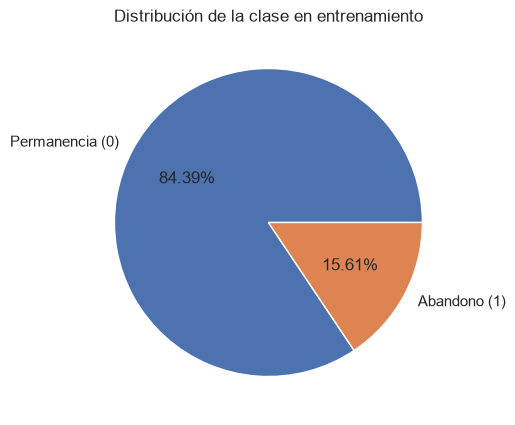

Porcentaje de abandono: 15.61
Accuracy de responder siempre 0: 0.8439


In [25]:
conteo = y_train.value_counts().reindex([0, 1], fill_value=0)
print(conteo)

plt.figure(figsize=(5, 5))
plt.pie(
    conteo,
    labels=["Permanencia (0)", "Abandono (1)"],
    autopct="%.2f%%"
)
plt.title("Distribución de la clase en entrenamiento")
plt.savefig(
    RUTA_FIGURAS + "01_distribucion_clase.png",
    bbox_inches="tight", dpi=150
)
plt.show()

print("Porcentaje de abandono:", round(y_train.mean() * 100, 2))
print("Accuracy de responder siempre 0:", round(conteo[0] / len(train), 4))

Encontramos 392 abandonos (15,61 %) y 2.119 permanencias (84,39 %). Responder siempre permanencia consigue 84,39 % de accuracy, pero no detecta ningún abandono. Usaremos F1 como métrica principal.


## Variables categóricas

Revisamos quejas, nivel de cargo, grupo de edad y plan tarifario.
Para cada categoría mostramos su cantidad de registros y su porcentaje de abandono.

Un porcentaje alto basado en muy pocas filas debe interpretarse con cuidado.
Estas asociaciones no demuestran causalidad.

,cantidad,porcentaje_abandono
quejas,,
0,2316,9.930915
1,195,83.076923


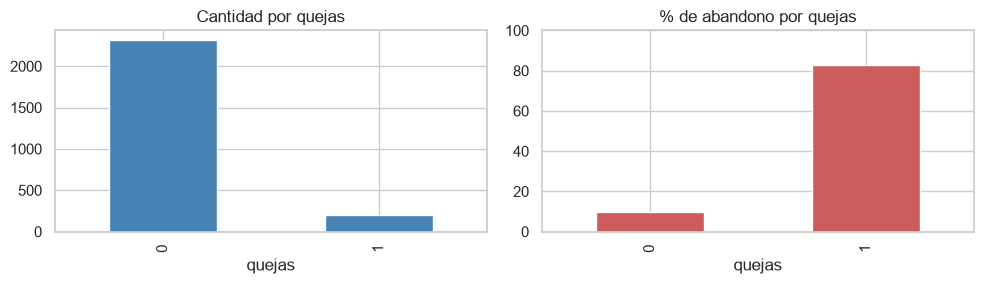

,cantidad,porcentaje_abandono
nivel_cargo,,
0,1394,23.457676
1,494,7.692308
2,316,6.329114
3,165,3.636364
4,60,1.666667
5,25,0.000000
6,10,0.000000
7,13,0.000000
8,18,0.000000


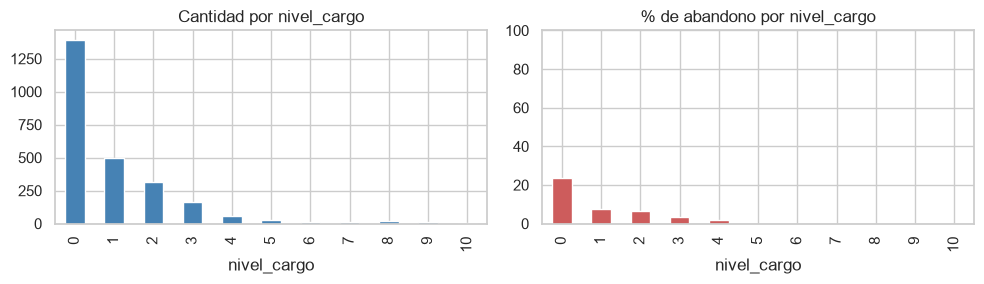

,cantidad,porcentaje_abandono
grupo_edad,,
1,101,0.000000
2,809,17.799753
3,1159,16.048318
4,306,19.934641
5,136,0.735294


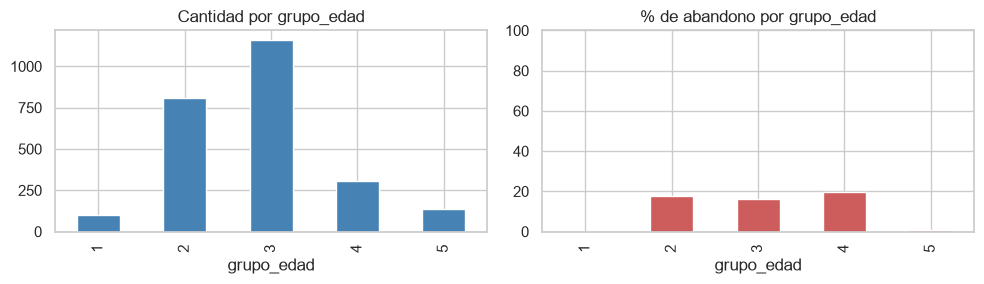

,cantidad,porcentaje_abandono
plan_tarifario,,
1,2320,16.724138
2,191,2.094241


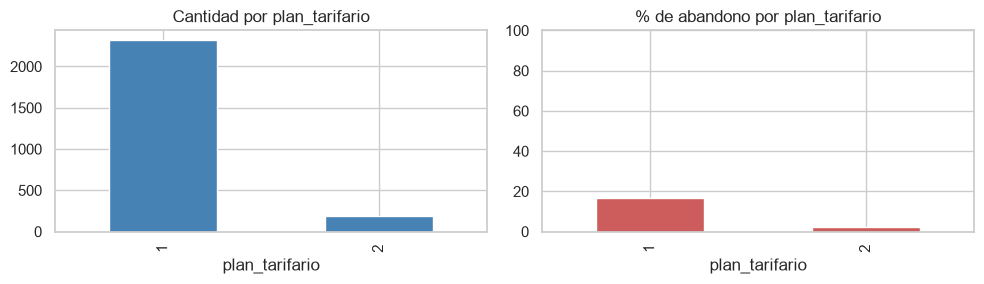

In [26]:
columnas_categoricas = [
    "quejas", "nivel_cargo", "grupo_edad", "plan_tarifario"
]

for columna in columnas_categoricas:
    resumen = train.groupby(columna)["abandono"].agg(
        cantidad="size",
        porcentaje_abandono="mean"
    )
    resumen["porcentaje_abandono"] *= 100

    display(resumen)

    fig, ejes = plt.subplots(1, 2, figsize=(10, 3))

    resumen["cantidad"].plot.bar(ax=ejes[0], color="steelblue")
    resumen["porcentaje_abandono"].plot.bar(
        ax=ejes[1], color="indianred"
    )

    ejes[0].set_title("Cantidad por " + columna)
    ejes[1].set_title("% de abandono por " + columna)
    ejes[1].set_ylim(0, 100)

    plt.tight_layout()
    plt.savefig(
        RUTA_FIGURAS + "01_categorica_" + columna + ".png",
        bbox_inches="tight", dpi=150
    )
    plt.show()

Entre los 195 registros con quejas, el 83,08 % corresponde a abandono; entre los 2.316 sin quejas, el 9,93 %. En el plan 1 observamos 16,72 % de abandono y en el plan 2, 2,09 %. Las categorías de cargo 5 a 10 tienen entre 7 y 25 registros cada una y ningún abandono observado: esto no demuestra que su riesgo real sea cero.


## Variables numéricas

Observamos sus distribuciones y comparamos permanencia con abandono.
Conservamos los valores extremos: aparecer lejos del resto no demuestra un error.

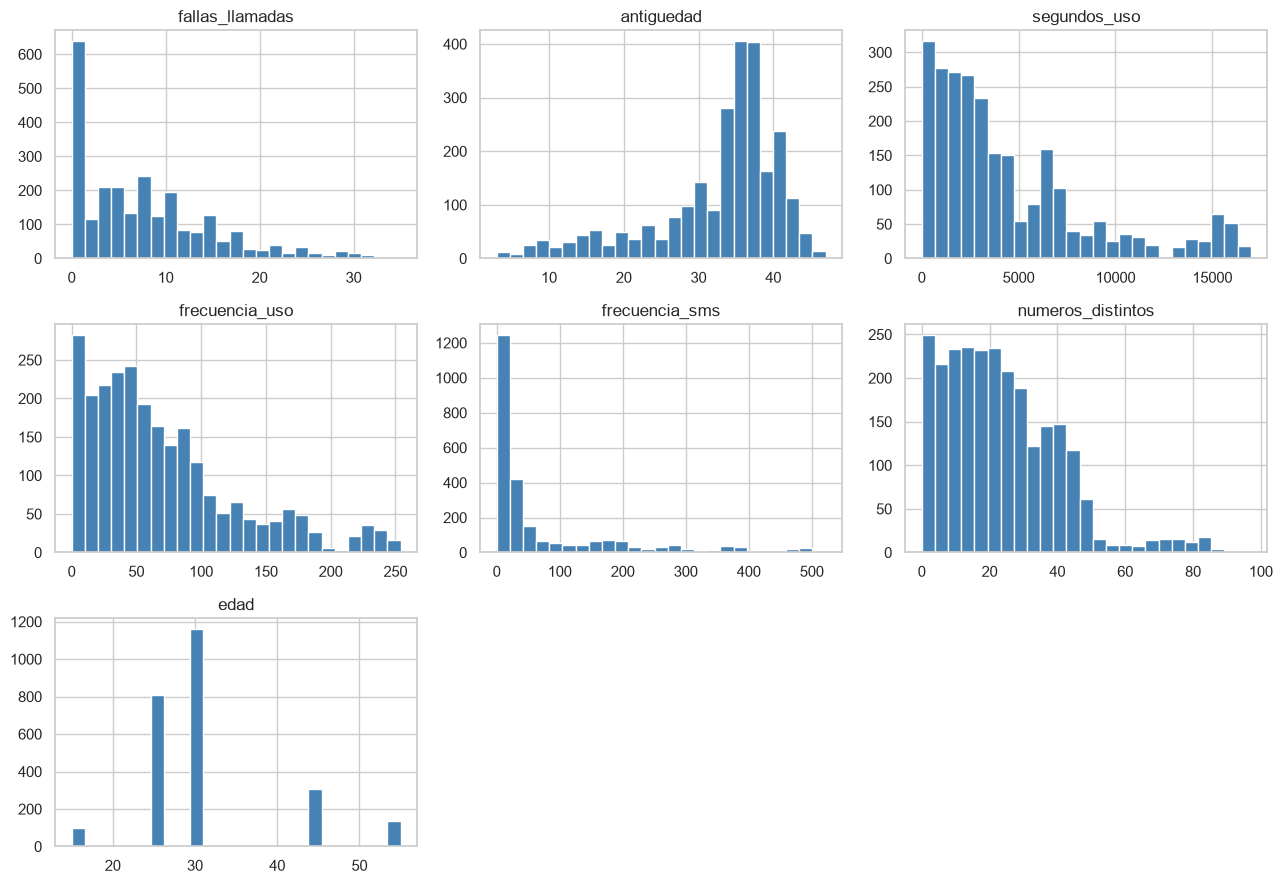

In [27]:
columnas_numericas = []

for columna in X_train.columns:
    if columna not in columnas_categoricas:
        columnas_numericas.append(columna)

fig, ejes = plt.subplots(3, 3, figsize=(13, 9))
ejes = ejes.flatten()

for i, columna in enumerate(columnas_numericas):
    ejes[i].hist(train[columna], bins=25, color="steelblue")
    ejes[i].set_title(columna)

for i in range(len(columnas_numericas), len(ejes)):
    ejes[i].axis("off")

plt.tight_layout()
plt.savefig(RUTA_FIGURAS + "01_histogramas.png", dpi=150)
plt.show()

En segundos de uso, la media es 4.509,15 y la mediana 3.020. En frecuencia de SMS, la media es 72,24 y la mediana 21. Estas diferencias y los histogramas muestran concentraciones en valores bajos con colas hacia valores altos.


Comparamos cada variable numérica entre las dos clases mediante diagramas de caja.
Buscamos diferencias de distribución, sin seleccionar todavía las entradas.

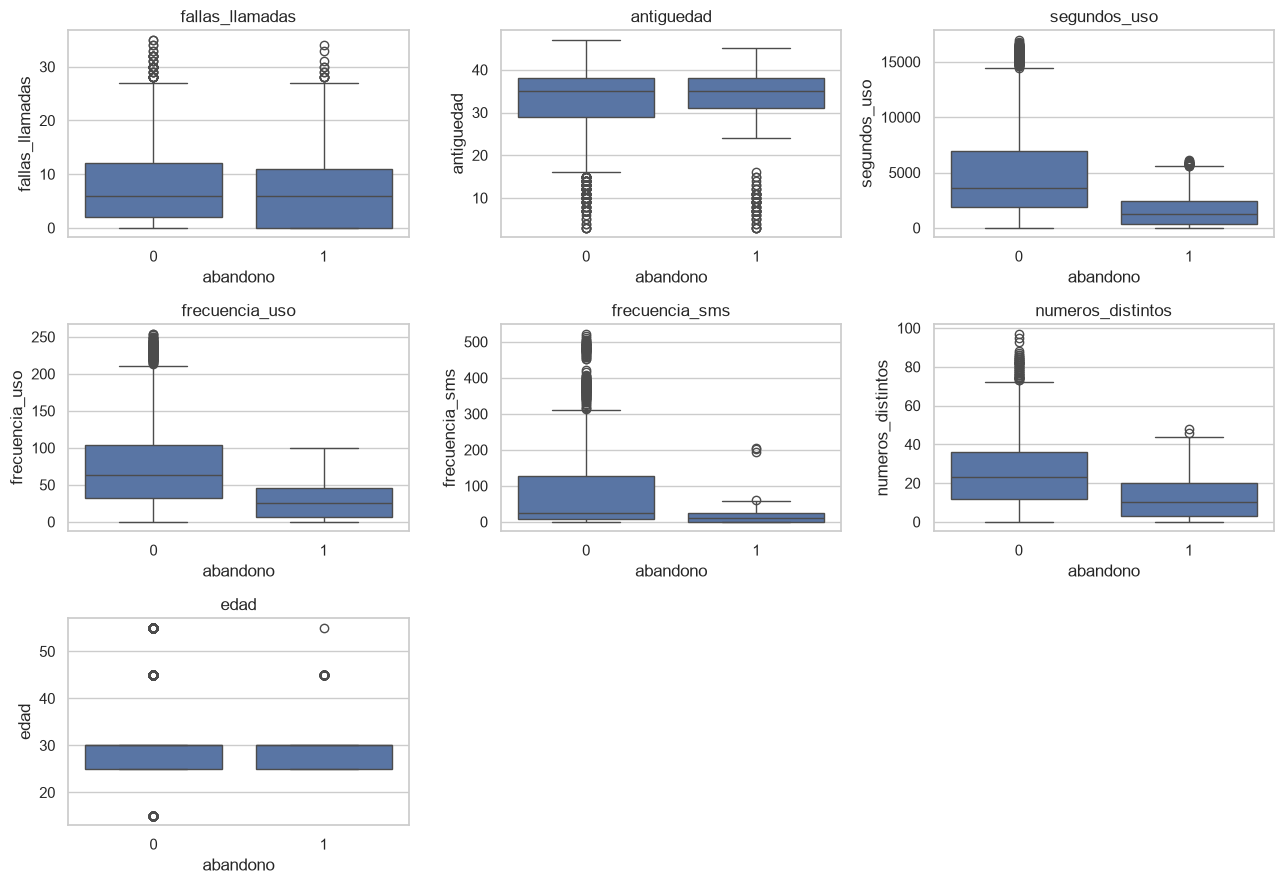

In [28]:
fig, ejes = plt.subplots(3, 3, figsize=(13, 9))
ejes = ejes.flatten()

for i, columna in enumerate(columnas_numericas):
    sns.boxplot(
        data=train, x="abandono", y=columna, ax=ejes[i]
    )
    ejes[i].set_title(columna)

for i in range(len(columnas_numericas), len(ejes)):
    ejes[i].axis("off")

plt.tight_layout()
plt.savefig(RUTA_FIGURAS + "01_boxplots_por_clase.png", dpi=150)
plt.show()

La mediana de segundos de uso es 1.235,5 en abandono y 3.603 en permanencia. La mediana de frecuencia de uso es 25 frente a 63. En entrenamiento, el abandono se asocia con menor uso, sin demostrar una relación causal.


## Asociaciones con phik

Como en el proyecto de sismos, usamos phik para explorar asociaciones entre
variables numéricas y categóricas.

Indicamos cuáles son numéricas. Las demás, incluida la respuesta, se tratan
como categorías. No eliminamos variables basándonos solamente en esta gráfica.

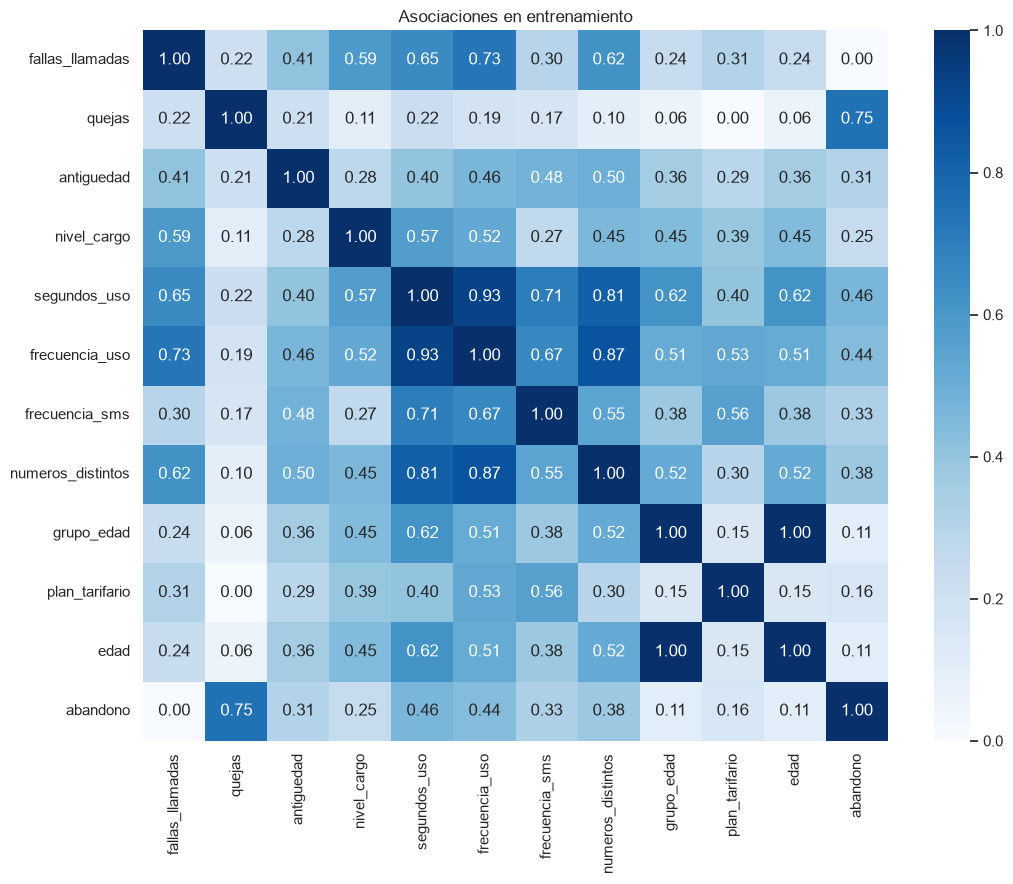

quejas               0.747024
segundos_uso         0.464021
frecuencia_uso       0.435297
numeros_distintos    0.379280
frecuencia_sms       0.331484
antiguedad           0.312303
nivel_cargo          0.248156
plan_tarifario       0.160914
grupo_edad           0.109489
edad                 0.109489
fallas_llamadas      0.000000
Name: abandono, dtype: float64

In [29]:
matriz_phik = train.phik_matrix(
    interval_cols=columnas_numericas,
    njobs=1
)

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_phik,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.title("Asociaciones en entrenamiento")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + "01_correlacion_phik.png", dpi=150)
plt.show()

matriz_phik.to_csv(RUTA_RESULTADOS + "01_phik_train.csv")

matriz_phik["abandono"].drop("abandono").sort_values(ascending=False)


Las mayores asociaciones phik con abandono son quejas (0,747), segundos de uso (0,464) y frecuencia de uso (0,435). Fallas de llamadas obtiene 0,000 con esta medida, lo que no demuestra que sea inútil en combinación con otras entradas. No seleccionamos rasgos en este punto.


## Posible redundancia entre edad y grupo de edad

Mostramos las parejas observadas solamente en entrenamiento para comprobar si ambas columnas representan la misma información.


In [30]:
relacion_edades = train[["edad", "grupo_edad"]].drop_duplicates().sort_values("edad")
display(relacion_edades)
print("Grupos distintos por edad:", train.groupby("edad")["grupo_edad"].nunique().max())
print("Edades distintas por grupo:", train.groupby("grupo_edad")["edad"].nunique().max())


,edad,grupo_edad
3,15,1
1,25,2
0,30,3
41,45,4
23,55,5


Grupos distintos por edad: 1
Edades distintas por grupo: 1


Observamos cinco parejas: 15–1, 25–2, 30–3, 45–4 y 55–5. Cada edad corresponde a un único grupo y viceversa. Conservamos ambas entradas y dejamos documentada la redundancia para el notebook 02.


## Guardar los datos

Guardamos entrenamiento, prueba, una copia original de prueba y los grupos
de entrenamiento. Los grupos quedan en el mismo orden que las filas de train.

Conservamos los archivos existentes. Prueba queda reservada para la evaluación
final del notebook 04.
Comprobamos que los CSV existentes coinciden con lo que corresponde guardar.
La comparación es de integridad del archivo, sin explorar ni evaluar prueba.
Si alguno no coincide, detenemos la ejecución en lugar de ignorarlo o sustituirlo.


In [31]:
grupos_exportar = pd.DataFrame({
    "fila_original": train.index,
    "grupo": grupos_train.to_numpy()
})

archivos = {
    "train.csv": train,
    "test.csv": datos.loc[mascara_test],
    "test_original.csv": datos_originales.loc[mascara_test],
    "grupos_train.csv": grupos_exportar
}

# Verificamos todos los existentes antes de escribir cualquier archivo faltante.
for nombre, contenido in archivos.items():
    ruta = RUTA_DATOS + nombre
    if os.path.exists(ruta):
        with open(ruta, encoding="utf-8", newline=None) as archivo:
            texto_guardado = archivo.read()
        texto_esperado = contenido.to_csv(index=False, lineterminator="\n")
        assert texto_guardado == texto_esperado, "Archivo incompatible: " + nombre

for nombre, contenido in archivos.items():
    ruta = RUTA_DATOS + nombre
    if os.path.exists(ruta):
        print("Verificado, se conserva:", nombre)
    else:
        contenido.to_csv(ruta, index=False, mode="x")
        print("Guardado:", nombre)

with open(ruta_original, "rb") as archivo:
    assert hashlib.sha256(archivo.read()).hexdigest() == huella

print("Original intacto y archivos coherentes con la partición.")


Verificado, se conserva: train.csv
Verificado, se conserva: test.csv
Verificado, se conserva: test_original.csv
Verificado, se conserva: grupos_train.csv
Original intacto y archivos coherentes con la partición.


## Conclusiones

Conservamos las 3.150 filas del original y dejamos once entradas más la respuesta.
No encontramos faltantes. Mantuvimos repeticiones, valores extremos y los siete
registros de nivel de cargo 10. Excluimos inicialmente `Status` y `Customer Value`
por la documentación pendiente sobre su construcción, no porque hayamos demostrado fuga.

Reutilizamos la partición guardada: 2.511 filas de entrenamiento y 639 de prueba,
sin perfiles compartidos. Los grupos se construyen con las once entradas, sin la
respuesta; conservamos las etiquetas distintas dentro de un mismo perfil.
Estos grupos deben mantenerse también en la validación cruzada.

En entrenamiento hay 392 abandonos (15,61 %) y 2.119 permanencias (84,39 %).
Responder siempre permanencia tendría 84,39 % de accuracy y F1 de abandono igual a cero.
Por eso nuestra métrica principal será F1, acompañada de precisión y recall.

Las mayores asociaciones phik con abandono fueron quejas (0,747), segundos de uso
(0,464) y frecuencia de uso (0,435). Entre los registros con quejas, el 83,08 %
corresponde a abandono, frente al 9,93 % entre quienes no registraron quejas.
Estas asociaciones no demuestran causalidad ni garantizan el desempeño de un modelo.

Edad y grupo de edad tienen correspondencia uno a uno en entrenamiento. Documentamos
esta redundancia para revisarla en el notebook 02; conservamos ambas por ahora.

Guardamos train.csv, test.csv, test_original.csv, grupos_train.csv y la partición,
además de las figuras y tablas del análisis. No entrenamos modelos, escalamos ni
balanceamos. La prueba se mantiene reservada para la evaluación final.

El siguiente paso del plan es revisar la viabilidad con modelos sencillos y
validación cruzada por grupos, usando únicamente entrenamiento.
